# Task 1: Data Preprocessing and Exploratory Data Analysis

## Objective

The objective of this task is to collect, preprocess, and analyze historical financial data for Tesla (TSLA), Vanguard Total Bond Market ETF (BND), and SPDR S&P 500 ETF (SPY). This exploratory analysis provides the foundation for building reliable forecasting models in later stages of the project.

## Dataset

Historical market data is obtained from the Yahoo Finance API using the `yfinance` Python package.

Assets analyzed:

- **TSLA** – Tesla Inc.
- **BND** – Vanguard Total Bond Market ETF
- **SPY** – SPDR S&P 500 ETF

Analysis period:

**January 1, 2015 – June 30, 2026**

This notebook covers:

- Data extraction
- Data cleaning
- Exploratory Data Analysis (EDA)
- Stationarity testing
- Volatility analysis
- Risk metrics (Sharpe Ratio and Value at Risk)

## Import Required Libraries

The following libraries are used for data manipulation, visualization, statistical analysis, and downloading financial data.

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Data acquisition
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy.stats import zscore
from statsmodels.tsa.stattools import adfuller

# Notebook settings
plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Download Historical Market Data

Historical daily market data is collected using the Yahoo Finance API through the `yfinance` package.

Assets:

- Tesla (TSLA)
- Vanguard Total Bond Market ETF (BND)
- SPDR S&P 500 ETF (SPY)

The data spans from **January 1, 2015** to **June 30, 2026**.

In [2]:
START_DATE = "2015-01-01"
END_DATE = "2026-06-30"

tickers = {
    "TSLA": "Tesla",
    "BND": "Vanguard Total Bond Market ETF",
    "SPY": "SPDR S&P 500 ETF"
}

data = {}

for ticker in tickers:
    df = yf.download(
        ticker,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=False,
        progress=False
    )

    df["Ticker"] = ticker
    data[ticker] = df

print("Data downloaded successfully.")

Data downloaded successfully.


In [3]:
for ticker, df in data.items():
    print(f"\n{'='*50}")
    print(f"{ticker}")
    print(df.head())


TSLA
Price      Adj Close   Close    High     Low    Open    Volume Ticker
Ticker          TSLA    TSLA    TSLA    TSLA    TSLA      TSLA       
Date                                                                 
2015-01-02   14.6207 14.6207 14.8833 14.2173 14.8580  71466000   TSLA
2015-01-05   14.0060 14.0060 14.4333 13.8107 14.3033  80527500   TSLA
2015-01-06   14.0853 14.0853 14.2800 13.6140 14.0040  93928500   TSLA
2015-01-07   14.0633 14.0633 14.3187 13.9853 14.2233  44526000   TSLA
2015-01-08   14.0413 14.0413 14.2533 14.0007 14.1873  51637500   TSLA

BND
Price      Adj Close   Close    High     Low    Open   Volume Ticker
Ticker           BND     BND     BND     BND     BND      BND       
Date                                                                
2015-01-02   59.2057 82.6500 82.6900 82.4200 82.4300  2218800    BND
2015-01-05   59.3775 82.8900 82.9200 82.7000 82.7400  5820100    BND
2015-01-06   59.5495 83.1300 83.3800 83.0300 83.0300  3887600    BND
2015-01-07   59

In [4]:
import os

os.makedirs("../data/raw", exist_ok=True)

for ticker, df in data.items():
    df.to_csv(f"../data/raw/{ticker}.csv")

print("Raw datasets saved successfully.")

Raw datasets saved successfully.


## Data Inspection and Cleaning

Before performing exploratory analysis, the datasets are inspected to ensure data quality. This includes:

- Examining dataset dimensions
- Checking data types
- Identifying missing values
- Detecting duplicate records
- Flattening MultiIndex columns returned by `yfinance`
- Verifying chronological ordering

In [5]:
# Flatten MultiIndex columns if present
for ticker, df in data.items():
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    data[ticker] = df

In [13]:
for ticker, df in data.items():
    df.columns.name = None

In [6]:
for ticker, df in data.items():
    print(f"\n{ticker}")
    print(df.columns.tolist())


TSLA
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker']

BND
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker']

SPY
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker']


In [14]:
for ticker, df in data.items():
    print("=" * 60)
    print(ticker)
    print(f"Shape: {df.shape}")
    display(df.head())

TSLA
Shape: (2888, 7)


,Adj Close,Close,High,Low,Open,Volume,Ticker
Date,,,,,,,
2015-01-02,14.6207,14.6207,14.8833,14.2173,14.8580,71466000,TSLA
2015-01-05,14.0060,14.0060,14.4333,13.8107,14.3033,80527500,TSLA
2015-01-06,14.0853,14.0853,14.2800,13.6140,14.0040,93928500,TSLA
2015-01-07,14.0633,14.0633,14.3187,13.9853,14.2233,44526000,TSLA
2015-01-08,14.0413,14.0413,14.2533,14.0007,14.1873,51637500,TSLA


BND
Shape: (2888, 7)


,Adj Close,Close,High,Low,Open,Volume,Ticker
Date,,,,,,,
2015-01-02,59.2057,82.6500,82.6900,82.4200,82.4300,2218800,BND
2015-01-05,59.3775,82.8900,82.9200,82.7000,82.7400,5820100,BND
2015-01-06,59.5495,83.1300,83.3800,83.0300,83.0300,3887600,BND
2015-01-07,59.5853,83.1800,83.2800,83.0500,83.1400,2433400,BND
2015-01-08,59.4922,83.0500,83.1100,82.9700,83.1100,1873400,BND


SPY
Shape: (2888, 7)


,Adj Close,Close,High,Low,Open,Volume,Ticker
Date,,,,,,,
2015-01-02,169.6879,205.4300,206.8800,204.1800,206.3800,121465900,SPY
2015-01-05,166.6233,201.7200,204.3700,201.3500,204.1700,169632600,SPY
2015-01-06,165.0539,199.8200,202.7200,198.8600,202.0900,209151400,SPY
2015-01-07,167.1107,202.3100,202.7200,200.8800,201.4200,125346700,SPY
2015-01-08,170.0761,205.9000,206.1600,203.9900,204.0100,147217800,SPY


In [15]:
for ticker, df in data.items():
    print("=" * 60)
    print(ticker)
    print(df.dtypes)

TSLA
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
Ticker           str
dtype: object
BND
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
Ticker           str
dtype: object
SPY
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
Ticker           str
dtype: object


In [16]:
for ticker, df in data.items():
    print("=" * 60)
    print(ticker)
    print(df.isnull().sum())

TSLA
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
Ticker       0
dtype: int64
BND
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
Ticker       0
dtype: int64
SPY
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
Ticker       0
dtype: int64


In [10]:
for ticker, df in data.items():
    duplicates = df.duplicated().sum()
    print(f"{ticker}: {duplicates} duplicate rows")

TSLA: 0 duplicate rows
BND: 0 duplicate rows
SPY: 0 duplicate rows


In [17]:
for ticker, df in data.items():
    print("=" * 60)
    print(ticker)
    display(df.describe())

TSLA


,Adj Close,Close,High,Low,Open,Volume
count,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000
mean,148.7739,148.7739,151.9906,145.4167,148.7973,108792194.4598
std,138.8960,138.8960,141.8528,135.8672,138.9772,70825493.1529
min,9.5780,9.5780,10.3313,9.4033,9.4880,10620000.0000
25%,18.3935,18.3935,18.6652,18.0237,18.3908,65483250.0000
50%,133.4377,133.4377,136.0533,125.8317,131.4963,90336150.0000
75%,251.9258,251.9258,257.4850,245.8325,251.6800,126120450.0000
max,489.8800,489.8800,498.8300,485.3300,489.8800,914082000.0000


BND


,Adj Close,Close,High,Low,Open,Volume
count,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000
mean,66.2811,79.3277,79.4421,79.2112,79.3307,4653785.8033
std,4.7001,5.3104,5.2980,5.3225,5.3138,3017703.9497
min,58.5318,68.0400,68.3800,67.9900,68.0800,0.0000
25%,62.2680,73.8000,73.9200,73.6400,73.8000,2233700.0000
50%,65.5074,80.8150,80.9050,80.7100,80.8000,4280650.0000
75%,70.4514,83.4400,83.5500,83.3325,83.4700,6246475.0000
max,74.5813,89.4800,89.5900,89.4400,89.5500,33963000.0000


SPY


,Adj Close,Close,High,Low,Open,Volume
count,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000,2888.0000
mean,351.5055,375.2167,377.1672,372.9466,375.1495,85510494.9792
std,155.4439,146.5847,147.2447,145.7748,146.5589,43385532.6469
min,154.1616,182.8600,184.1000,181.0200,182.3400,20270000.0000
25%,223.5468,254.5600,255.9200,252.4775,254.5775,58364550.0000
50%,312.8179,339.4350,342.3150,337.1650,339.8350,75419500.0000
75%,432.8068,453.6775,456.0000,451.5500,453.9900,98822450.0000
max,757.6182,759.5700,760.4000,756.7500,758.1500,507244300.0000


In [12]:
for ticker, df in data.items():
    print(
        f"{ticker}: "
        f"{df.index.min().date()} → {df.index.max().date()}"
    )

TSLA: 2015-01-02 → 2026-06-29
BND: 2015-01-02 → 2026-06-29
SPY: 2015-01-02 → 2026-06-29


### Data Quality Summary

The downloaded datasets were inspected before analysis to ensure their suitability for time series modeling.

**Key observations:**

- All three datasets (TSLA, BND, and SPY) contain **2,888 daily trading observations**.
- No missing values were detected in any dataset.
- No duplicate records were found.
- All numerical variables (`Open`, `High`, `Low`, `Close`, `Adj Close`, and `Volume`) have appropriate numeric data types.
- The `Ticker` column is stored as a string, serving as an asset identifier.
- The MultiIndex column structure returned by `yfinance` was flattened to simplify subsequent analysis.

Overall, the datasets were clean and required only minor structural preprocessing before feature engineering and exploratory data analysis.

## Feature Engineering

To better understand the behavior of each asset, additional time series features are created.

The following features are calculated:

- Daily percentage returns
- 30-day rolling mean
- 30-day rolling standard deviation (volatility)

In [18]:
for ticker, df in data.items():
    df["Daily Return"] = df["Adj Close"].pct_change()

In [19]:
WINDOW = 30

for ticker, df in data.items():
    df["Rolling Mean"] = (
        df["Adj Close"]
        .rolling(window=WINDOW)
        .mean()
    )

In [20]:
for ticker, df in data.items():
    df["Rolling Std"] = (
        df["Daily Return"]
        .rolling(window=WINDOW)
        .std()
    )

In [21]:
TRADING_DAYS = 252

volatility = {}

for ticker, df in data.items():
    annual_vol = (
        df["Daily Return"].std() * np.sqrt(TRADING_DAYS)
    )

    volatility[ticker] = annual_vol

volatility

{'TSLA': np.float64(0.5717745849232521),
 'BND': np.float64(0.053123163331785545),
 'SPY': np.float64(0.17654659071906126)}

### Volatility Analysis

Annualized volatility was calculated using the standard deviation of daily returns.

| Asset | Annualized Volatility |
|-------|----------------------:|
| TSLA | 57.18% |
| SPY | 17.65% |
| BND | 5.31% |

Tesla exhibited substantially higher volatility than both SPY and BND, reflecting its aggressive growth profile and greater exposure to market sentiment. SPY showed moderate volatility consistent with a diversified equity index, while BND remained the least volatile asset, reinforcing its role as a defensive investment.

In [22]:
for ticker, df in data.items():
    print("=" * 70)
    print(ticker)
    display(
        df[
            [
                "Adj Close",
                "Daily Return",
                "Rolling Mean",
                "Rolling Std",
            ]
        ].head(35)
    )

TSLA


,Adj Close,Daily Return,Rolling Mean,Rolling Std
Date,,,,
2015-01-02,14.6207,NaN,NaN,NaN
2015-01-05,14.0060,-0.0420,NaN,NaN
2015-01-06,14.0853,0.0057,NaN,NaN
2015-01-07,14.0633,-0.0016,NaN,NaN
2015-01-08,14.0413,-0.0016,NaN,NaN
2015-01-09,13.7773,-0.0188,NaN,NaN
2015-01-12,13.4807,-0.0215,NaN,NaN
2015-01-13,13.6167,0.0101,NaN,NaN
2015-01-14,12.8460,-0.0566,NaN,NaN


BND


,Adj Close,Daily Return,Rolling Mean,Rolling Std
Date,,,,
2015-01-02,59.2057,NaN,NaN,NaN
2015-01-05,59.3775,0.0029,NaN,NaN
2015-01-06,59.5495,0.0029,NaN,NaN
2015-01-07,59.5853,0.0006,NaN,NaN
2015-01-08,59.4922,-0.0016,NaN,NaN
2015-01-09,59.5925,0.0017,NaN,NaN
2015-01-12,59.6713,0.0013,NaN,NaN
2015-01-13,59.7286,0.0010,NaN,NaN
2015-01-14,59.8647,0.0023,NaN,NaN


SPY


,Adj Close,Daily Return,Rolling Mean,Rolling Std
Date,,,,
2015-01-02,169.6879,NaN,NaN,NaN
2015-01-05,166.6233,-0.0181,NaN,NaN
2015-01-06,165.0539,-0.0094,NaN,NaN
2015-01-07,167.1107,0.0125,NaN,NaN
2015-01-08,170.0761,0.0177,NaN,NaN
2015-01-09,168.7132,-0.0080,NaN,NaN
2015-01-12,167.3916,-0.0078,NaN,NaN
2015-01-13,166.9207,-0.0028,NaN,NaN
2015-01-14,165.9129,-0.0060,NaN,NaN


## Closing Price Trends

This visualization illustrates how the adjusted closing prices of Tesla (TSLA), Vanguard Total Bond Market ETF (BND), and SPDR S&P 500 ETF (SPY) evolved over time.

The chart provides a first look at long-term growth patterns and relative price movements across the three assets.

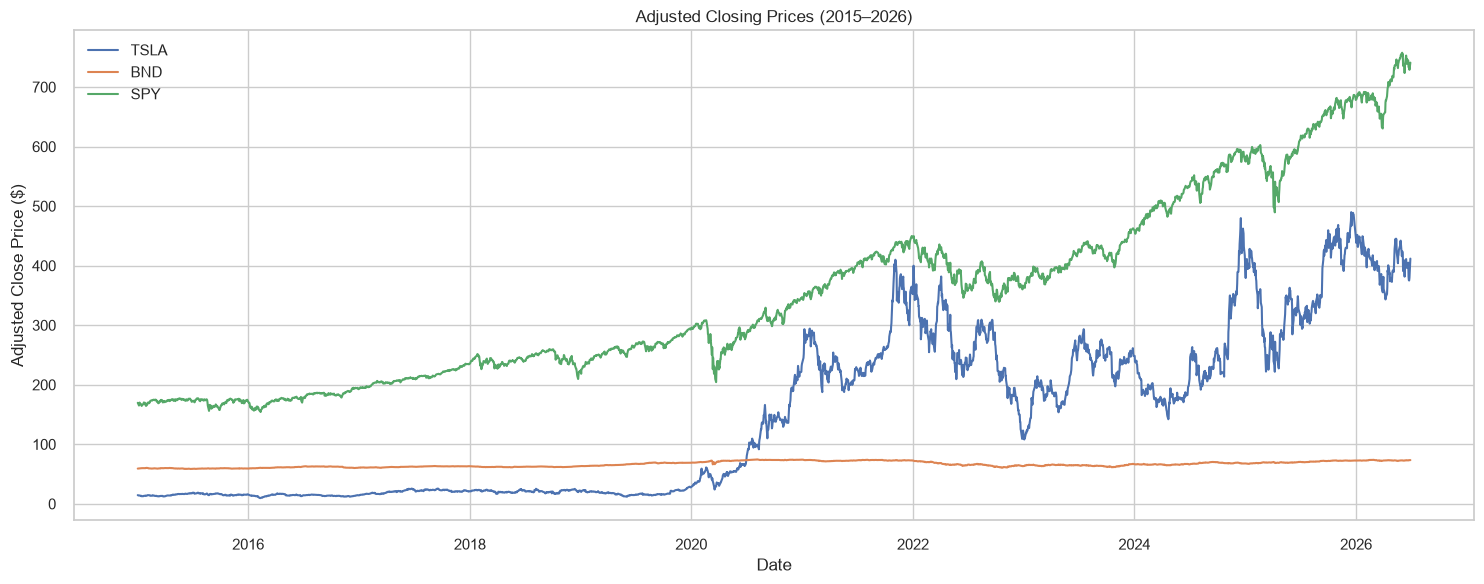

In [23]:
fig, ax = plt.subplots(figsize=(15,6))

for ticker, df in data.items():
    ax.plot(df.index, df["Adj Close"], label=ticker)

ax.set_title("Adjusted Closing Prices (2015–2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close Price ($)")
ax.legend()

plt.tight_layout()
plt.show()

## Daily Percentage Returns

Daily returns measure the percentage change in adjusted closing prices from one trading day to the next.

They provide insight into short-term volatility and investment risk.

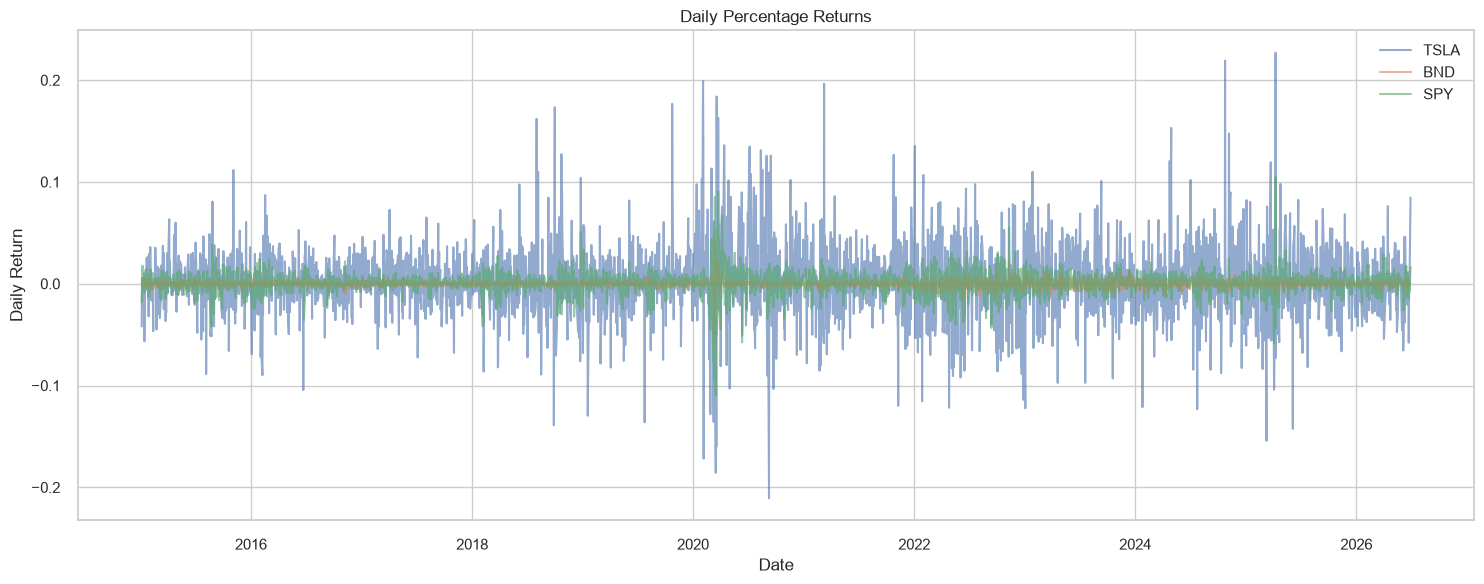

In [24]:
fig, ax = plt.subplots(figsize=(15,6))

for ticker, df in data.items():
    ax.plot(
        df.index,
        df["Daily Return"],
        alpha=0.6,
        label=ticker
    )

ax.set_title("Daily Percentage Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Return")

ax.legend()

plt.tight_layout()
plt.show()

## Rolling Mean & Rolling Volatility

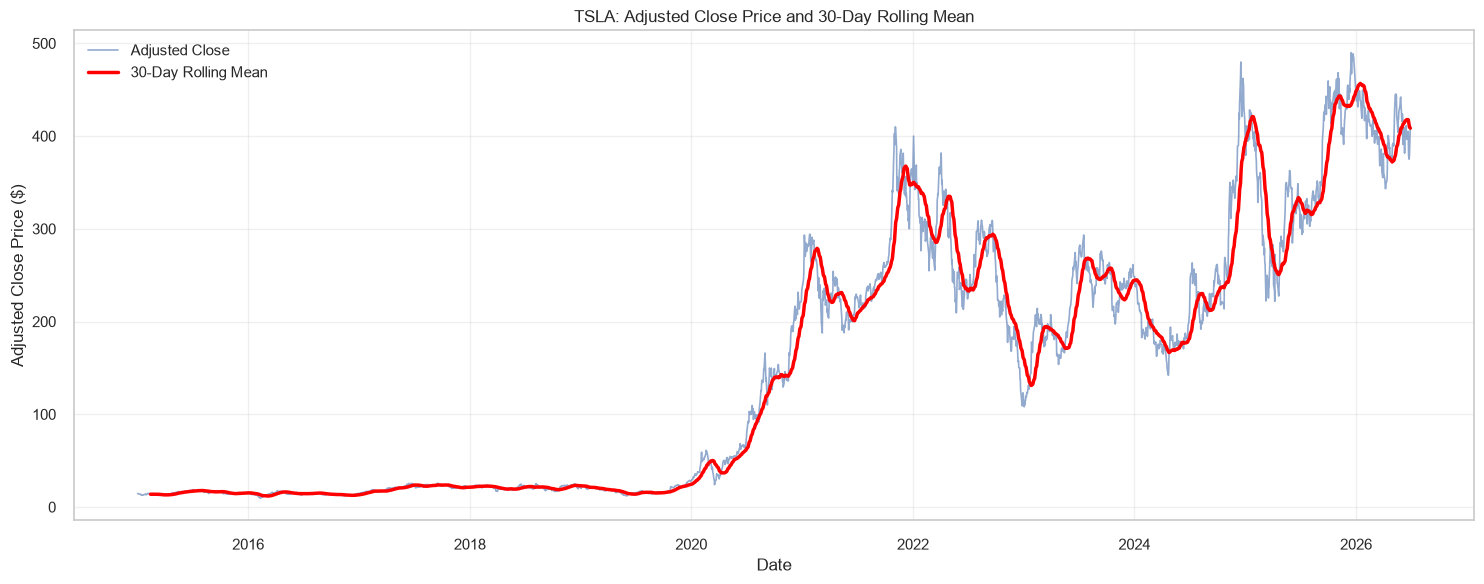

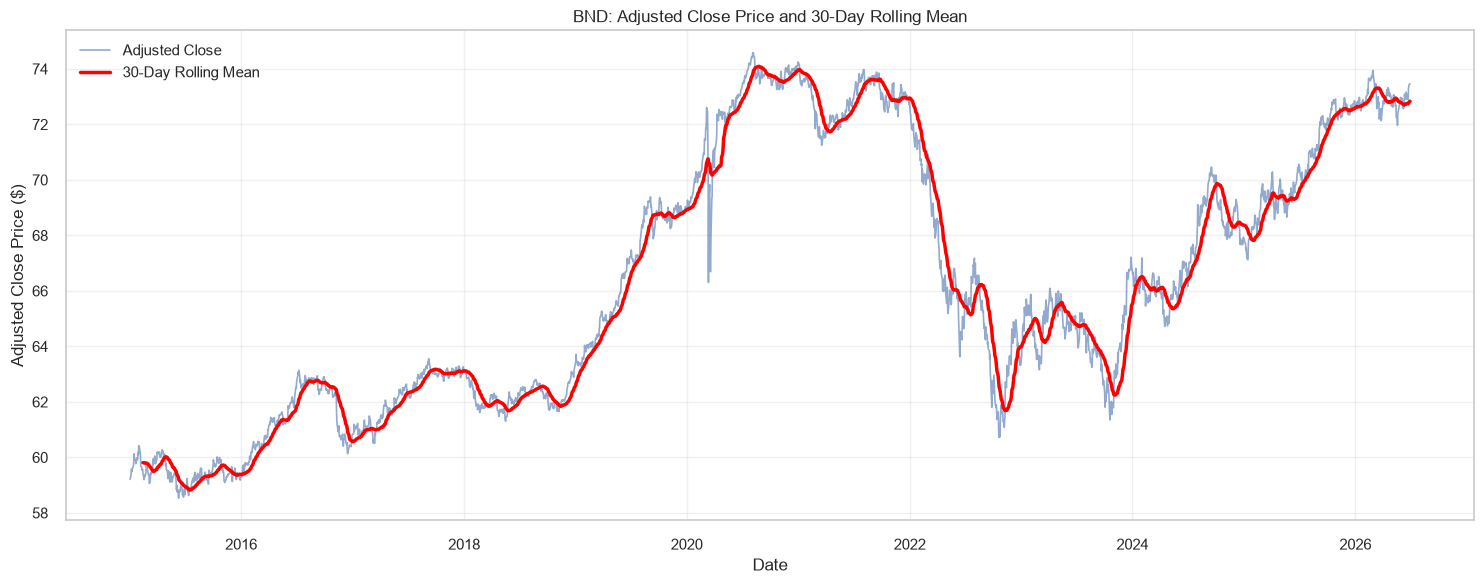

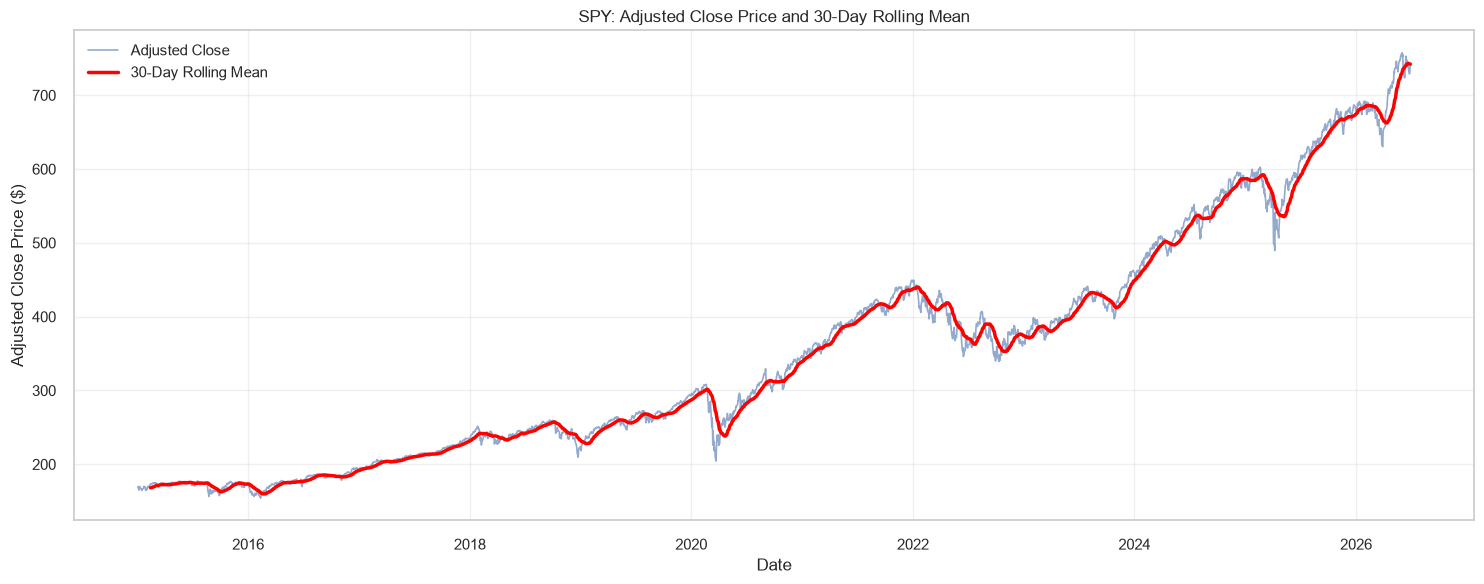

In [32]:
for ticker, df in data.items():

    plt.figure(figsize=(15, 6))

    plt.plot(
        df.index,
        df["Adj Close"],
        label="Adjusted Close",
        alpha=0.6,
        linewidth=1.2
    )

    plt.plot(
        df.index,
        df["Rolling Mean"],
        label="30-Day Rolling Mean",
        color="red",
        linewidth=2.5
    )

    plt.title(f"{ticker}: Adjusted Close Price and 30-Day Rolling Mean")
    plt.xlabel("Date")
    plt.ylabel("Adjusted Close Price ($)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

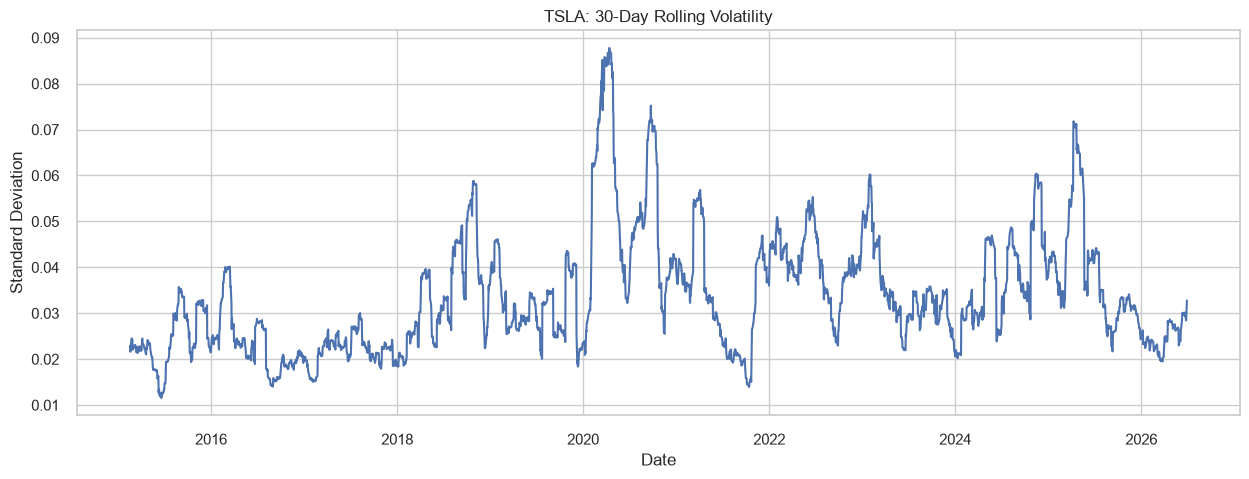

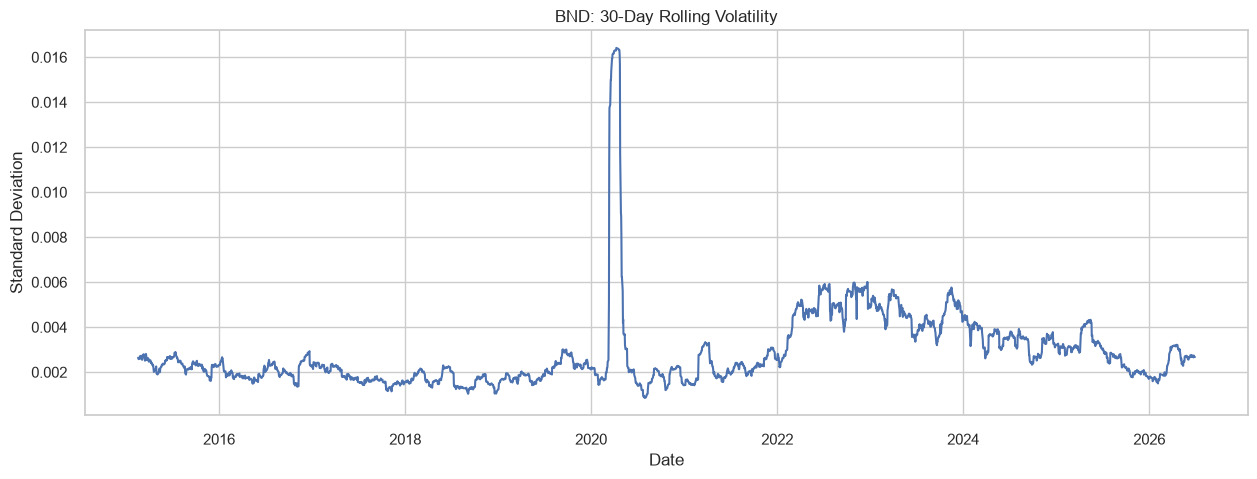

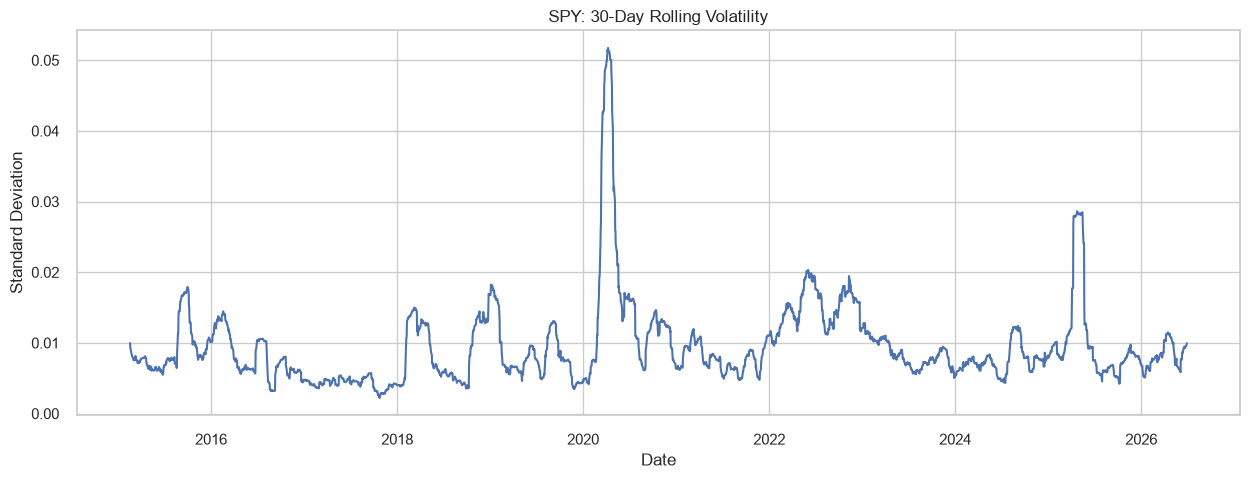

In [26]:
for ticker, df in data.items():

    plt.figure(figsize=(15,5))

    plt.plot(
        df.index,
        df["Rolling Std"]
    )

    plt.title(f"{ticker}: 30-Day Rolling Volatility")

    plt.xlabel("Date")

    plt.ylabel("Standard Deviation")

    plt.show()

## Exploratory Data Analysis Summary

The exploratory analysis revealed distinct characteristics for each of the three financial assets.

### Tesla (TSLA)

Tesla exhibited the highest level of volatility throughout the observation period. While its adjusted closing price experienced significant long-term growth, it also underwent several substantial corrections and periods of rapid price appreciation. Daily returns displayed the widest dispersion, and Tesla recorded the highest number of extreme return days (46), indicating a high-risk, high-return investment profile.

### Vanguard Total Bond Market ETF (BND)

BND showed relatively stable price movements over the entire period. Daily returns fluctuated within a narrow range, and annualized volatility was considerably lower than the equity assets. Although several isolated volatility spikes occurred during periods of market stress, BND behaved as a defensive asset suitable for portfolio risk reduction.

### SPDR S&P 500 ETF (SPY)

SPY demonstrated a consistent long-term upward trend while maintaining moderate volatility. Compared with Tesla, its daily returns were much more stable, reflecting the diversification benefits of tracking the broader U.S. equity market. Its behavior positions SPY between TSLA and BND in terms of both expected return and investment risk.

## Distribution Of Returns

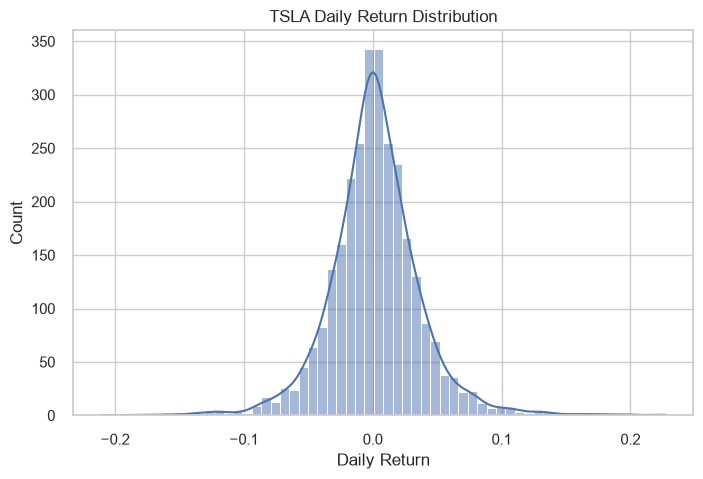

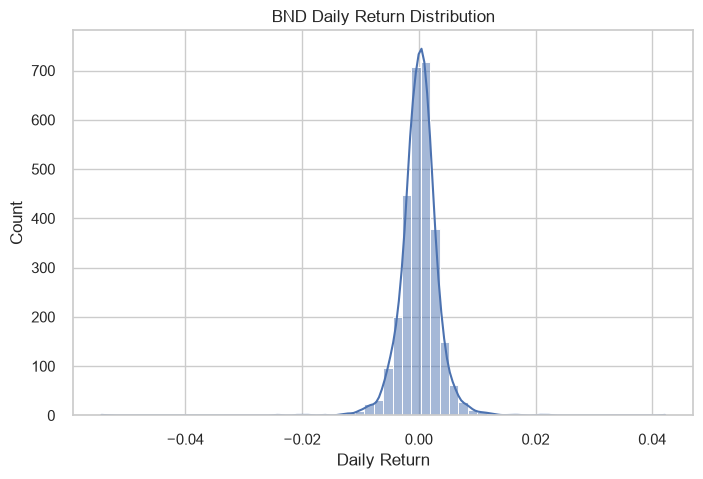

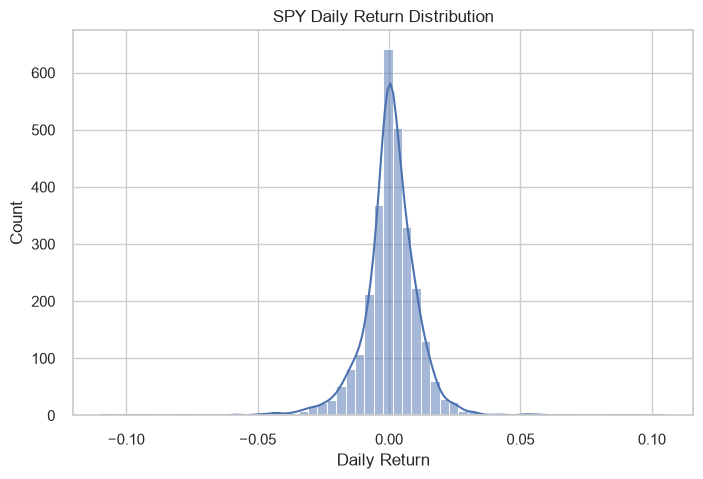

In [27]:
for ticker, df in data.items():

    plt.figure(figsize=(8,5))

    sns.histplot(
        df["Daily Return"].dropna(),
        bins=60,
        kde=True
    )

    plt.title(f"{ticker} Daily Return Distribution")

    plt.show()

## Correlation Heatmap

In [28]:
returns_df = pd.DataFrame({
    ticker: df["Daily Return"]
    for ticker, df in data.items()
})

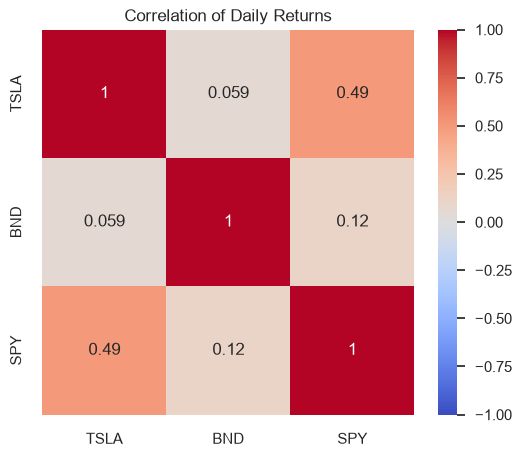

In [29]:
plt.figure(figsize=(6,5))

sns.heatmap(
    returns_df.corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation of Daily Returns")

plt.show()

### Correlation Analysis

The correlation matrix indicates varying relationships among the three assets.

- TSLA and SPY exhibit a **moderate positive correlation (0.49)**, suggesting that Tesla generally moves in the same direction as the broader equity market while retaining substantial company-specific behavior.
- BND shows **very weak correlations** with both TSLA (0.06) and SPY (0.12), highlighting its diversification potential within a mixed-asset portfolio.

These results support the inclusion of BND in portfolio optimization, as combining assets with low correlations can reduce overall portfolio risk according to Modern Portfolio Theory.

## Outlier Detection

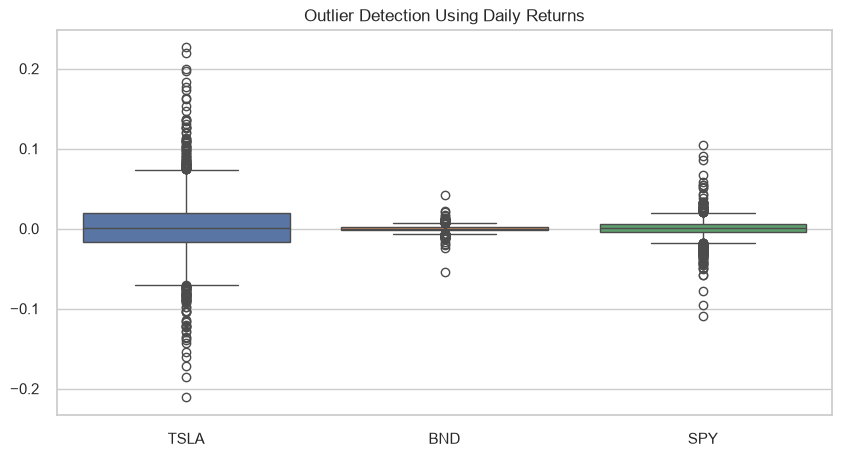

In [30]:
plt.figure(figsize=(10,5))

sns.boxplot(data=returns_df)

plt.title("Outlier Detection Using Daily Returns")

plt.show()

### Outlier Analysis

Outlier detection using daily returns identified several extreme market movements across all assets.

| Asset | Extreme Return Days |
|-------|--------------------:|
| TSLA | 46 |
| SPY | 39 |
| BND | 34 |

Tesla recorded the greatest number of extreme return days, consistent with its elevated volatility and sensitivity to market events. BND experienced the fewest extreme observations, further supporting its reputation as a relatively stable fixed-income investment.

## Extreme Return Days

In [31]:
from scipy.stats import zscore

for ticker, df in data.items():

    temp = df.copy()

    temp["Z"] = zscore(
        temp["Daily Return"].fillna(0)
    )

    outliers = temp[np.abs(temp["Z"]) > 3]

    print(
        f"{ticker}: {len(outliers)} extreme return days"
    )

    display(
        outliers[
            ["Adj Close", "Daily Return"]
        ].head()
    )

TSLA: 46 extreme return days


,Adj Close,Daily Return
Date,,
2015-11-04,15.4420,0.1117
2018-08-02,23.3027,0.1619
2018-08-07,25.3047,0.1099
2018-09-28,17.6513,-0.1390
2018-10-01,20.7133,0.1735


BND: 34 extreme return days


,Adj Close,Daily Return
Date,,
2020-03-10,71.4717,-0.0134
2020-03-11,70.1180,-0.0189
2020-03-12,66.3047,-0.0544
2020-03-13,69.1028,0.0422
2020-03-16,69.8292,0.0105


SPY: 39 extreme return days


,Adj Close,Daily Return
Date,,
2015-08-24,157.9930,-0.0421
2015-08-26,162.1283,0.0384
2016-06-24,173.1225,-0.0359
2018-02-05,231.7052,-0.0418
2018-02-08,226.1744,-0.0375


# Stationarity Analysis

Time series forecasting models such as ARIMA assume that the input series is stationary, meaning its statistical properties (mean and variance) remain constant over time.

The Augmented Dickey-Fuller (ADF) test is used to determine whether a time series is stationary.

### Hypotheses

- **Null Hypothesis (H₀):** The time series is non-stationary.
- **Alternative Hypothesis (H₁):** The time series is stationary.

A p-value less than **0.05** indicates that the null hypothesis can be rejected and the series can be considered stationary.

In [33]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=""):

    result = adfuller(series.dropna())

    labels = [
        "ADF Statistic",
        "p-value",
        "# Lags Used",
        "# Observations"
    ]

    print("="*60)
    print(title)

    for value, label in zip(result[:4], labels):
        print(f"{label}: {value}")

    print("\nCritical Values:")

    for key, value in result[4].items():
        print(f"{key}: {value:.4f}")

    if result[1] <= 0.05:
        print("\nResult: The series is stationary.")
    else:
        print("\nResult: The series is NOT stationary.")

In [34]:
for ticker, df in data.items():
    adf_test(
        df["Adj Close"],
        f"{ticker} - Adjusted Close"
    )

TSLA - Adjusted Close
ADF Statistic: -1.0695991394177442
p-value: 0.7270419411549228
# Lags Used: 27
# Observations: 2860

Critical Values:
1%: -3.4326
5%: -2.8626
10%: -2.5673

Result: The series is NOT stationary.
BND - Adjusted Close
ADF Statistic: -1.0478658074210045
p-value: 0.7354087170975732
# Lags Used: 13
# Observations: 2874

Critical Values:
1%: -3.4326
5%: -2.8625
10%: -2.5673

Result: The series is NOT stationary.
SPY - Adjusted Close
ADF Statistic: 1.3089437182937296
p-value: 0.9966585459168101
# Lags Used: 9
# Observations: 2878

Critical Values:
1%: -3.4326
5%: -2.8625
10%: -2.5673

Result: The series is NOT stationary.


In [38]:
for ticker, df in data.items():
    adf_test(
        df["Daily Return"],
        f"{ticker} - Daily Returns"
    )

TSLA - Daily Returns
ADF Statistic: -53.971892804251446
p-value: 0.0
# Lags Used: 0
# Observations: 2886

Critical Values:
1%: -3.4326
5%: -2.8625
10%: -2.5673

Result: The series is stationary.
BND - Daily Returns
ADF Statistic: -15.221210557012197
p-value: 5.4819724362054575e-28
# Lags Used: 12
# Observations: 2874

Critical Values:
1%: -3.4326
5%: -2.8625
10%: -2.5673

Result: The series is stationary.
SPY - Daily Returns
ADF Statistic: -17.572189859586395
p-value: 4.0462694016101636e-30
# Lags Used: 8
# Observations: 2878

Critical Values:
1%: -3.4326
5%: -2.8625
10%: -2.5673

Result: The series is stationary.


### Interpretation

The Augmented Dickey-Fuller tests indicate that the adjusted closing prices are non-stationary, whereas the daily return series are stationary.

This result is expected for financial market data. Stock prices generally exhibit long-term trends and changing levels over time, violating the stationarity assumption required by ARIMA models.

Daily returns remove much of this trend and fluctuate around a relatively constant mean, making them suitable for statistical modeling.

Consequently, the price series will require differencing before fitting ARIMA models in Task 2.

# Risk Metrics

Two commonly used financial risk measures are calculated:

- Historical Value at Risk (VaR)
- Sharpe Ratio

These metrics quantify downside risk and risk-adjusted performance, respectively.

In [35]:
confidence_level = 0.95

var_results = {}

for ticker, df in data.items():

    var = np.percentile(
        df["Daily Return"].dropna(),
        5
    )

    var_results[ticker] = var

var_df = pd.DataFrame.from_dict(
    var_results,
    orient="index",
    columns=["95% Historical VaR"]
)

var_df

,95% Historical VaR
TSLA,-0.0517
BND,-0.0048
SPY,-0.0167


### Value at Risk (VaR)

Historical Value at Risk (VaR) at the 95% confidence level estimates the maximum expected daily loss under normal market conditions.

| Asset | 95% Historical VaR |
|-------|-------------------:|
| TSLA | -5.17% |
| SPY | -1.67% |
| BND | -0.48% |

Tesla exhibits the largest downside risk, with a potential one-day loss of approximately 5.17% in the worst 5% of trading days. SPY has a more moderate downside risk, while BND demonstrates the smallest potential losses, reflecting its defensive nature and lower volatility.

## Sharpe Ration (Assuming a 2% annual risk-free rate)

In [36]:
risk_free_rate = 0.02

sharpe_results = {}

for ticker, df in data.items():

    annual_return = (
        df["Daily Return"].mean() * 252
    )

    annual_volatility = (
        df["Daily Return"].std() * np.sqrt(252)
    )

    sharpe = (
        annual_return - risk_free_rate
    ) / annual_volatility

    sharpe_results[ticker] = sharpe

sharpe_df = pd.DataFrame.from_dict(
    sharpe_results,
    orient="index",
    columns=["Sharpe Ratio"]
)

sharpe_df

,Sharpe Ratio
TSLA,0.7595
BND,0.0047
SPY,0.7042


### Sharpe Ratio

The Sharpe Ratio evaluates risk-adjusted performance by comparing excess returns to total volatility.

| Asset | Sharpe Ratio |
|-------|-------------:|
| TSLA | 0.7595 |
| SPY | 0.7042 |
| BND | 0.0047 |

Tesla achieved the highest risk-adjusted return over the analysis period, closely followed by SPY. BND produced a near-zero Sharpe Ratio, indicating that its relatively low returns barely exceeded the assumed risk-free rate despite its low volatility. This illustrates the trade-off between return and stability across the three assets.

In [37]:
risk_metrics = pd.concat(
    [var_df, sharpe_df],
    axis=1
)

risk_metrics

,95% Historical VaR,Sharpe Ratio
TSLA,-0.0517,0.7595
BND,-0.0048,0.0047
SPY,-0.0167,0.7042


# Key Findings

The exploratory analysis provided several important insights into the characteristics of the three financial assets.

- Tesla (TSLA) demonstrated the strongest long-term price appreciation but also the highest volatility and the largest number of extreme return days, confirming its high-risk, high-return profile.

- Vanguard Total Bond Market ETF (BND) remained the most stable asset throughout the observation period, exhibiting the lowest volatility and weakest correlation with the equity assets, making it valuable for diversification.

- SPDR S&P 500 ETF (SPY) showed steady long-term growth with moderate volatility, representing a balanced exposure to the overall U.S. equity market.

- Correlation analysis revealed that BND has relatively weak correlations with both TSLA and SPY, suggesting that including bonds can reduce overall portfolio risk.

- The Augmented Dickey-Fuller tests indicated that the adjusted closing price series are non-stationary, whereas daily returns are stationary. Consequently, differencing will be required before fitting ARIMA models.

- Historical Value at Risk (VaR) and Sharpe Ratio further highlighted the differences in the risk-return characteristics of the three assets and provide quantitative measures that will support portfolio optimization in later tasks.

Overall, the datasets are clean, complete, and suitable for forecasting and portfolio optimization.